**Prophet**:
- Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet is robust to missing data and shifts in the trend, and typically handles outliers well.
- Maybe don't need one that handles missing data if we don't have any

# Inputs

In [1]:
# Minimum viable dataframe -> two mandatory columns minimum

#Our data should already contain the datetime as index and all features as columns
# Data should be scaled.. Prophet handels target scaling and missings

#Target as extra input also with datetime index

import pandas as pd

df = pd.read_csv('preprocessed_data.csv')


# ds must be a proper datetime, not a string
df.datetime_utc12 = pd.to_datetime(df.datetime_utc12)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52585 entries, 0 to 52584
Data columns (total 81 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   datetime_utc12                        52585 non-null  datetime64[ns]
 1   el_price_dol_MWh_BEN2201              52585 non-null  float64       
 2   el_price_dol_MWh_HAY2201              52585 non-null  float64       
 3   el_price_dol_MWh_INV2201              52585 non-null  float64       
 4   el_price_dol_MWh_ISL2201              52585 non-null  float64       
 5   el_price_dol_MWh_KIK2201              52585 non-null  float64       
 6   el_price_dol_MWh_OTA2201              52585 non-null  float64       
 7   el_price_dol_MWh_RDF2201              52585 non-null  float64       
 8   el_price_dol_MWh_SFD2201              52585 non-null  float64       
 9   el_price_dol_MWh_WKM2201              52585 non-null  float64       
 10

# Lastmile Preprocesssing

In [2]:
# === Rebuild df_prophet: drop node prices, lag generation + demand by 24h ===
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1. Target + datetime
df_prophet = df[['datetime_utc12', 'el_price_dol_MWh_OTA2201']].rename(
    columns={'datetime_utc12': 'ds', 'el_price_dol_MWh_OTA2201': 'y'}
)

# 2. DROP all node-price columns + Direction
node_price_cols = [c for c in df.columns if 'el_price_dol_MWh' in c]
exclude_cols = node_price_cols + ['datetime_utc12', 'el_price_dol_MWh_OTA2201', 'Direction']
feature_cols = [c for c in df.columns if c not in exclude_cols]

# 3. Copy raw features into df_prophet and ffill BEFORE scaling
df_prophet[feature_cols] = df[feature_cols].values
df_prophet[feature_cols] = df_prophet[feature_cols].ffill()

# 4. Scale surviving features (now on gap-filled data)
scaler = MinMaxScaler()
df_prophet[feature_cols] = scaler.fit_transform(df_prophet[feature_cols])

# 5. Bring Direction back unscaled
df_prophet['Direction'] = df['Direction'].values

# 6. LAG generation + demand by 24h (both co-determined / unavailable at forecast time)
generation_cols = ['Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood']
demand_cols     = [c for c in df_prophet.columns if c.startswith('demand_GWh')]
lag_cols        = [c for c in (generation_cols + demand_cols) if c in df_prophet.columns]
for col in lag_cols:
    df_prophet[col] = df_prophet[col].shift(24)

# 7. Drop rows with NaN from the shift
df_prophet.dropna(inplace=True)
df_prophet.reset_index(drop=True, inplace=True)

print("Dropped node prices:", node_price_cols)
print("Lagged (generation + demand):", lag_cols)
print("Final shape:", df_prophet.shape)
print("Remaining feature count:", len([c for c in df_prophet.columns if c not in ['ds','y']]))
df_prophet.head()

Dropped node prices: ['el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201', 'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201', 'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_OTA2201', 'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201', 'el_price_dol_MWh_WKM2201']
Lagged (generation + demand): ['Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood', 'demand_GWh_CNI', 'demand_GWh_LNI', 'demand_GWh_LSI', 'demand_GWh_UNI', 'demand_GWh_USI']
Final shape: (52555, 73)
Remaining feature count: 71


,ds,y,Coal,Diesel,Ele,Gas,Geo,Hydro,Solar,Wind,...,demand_GWh_UNI,demand_GWh_USI,avg_flow_MW,peak_flow_MW,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW,Direction
0,2019-01-02 00:00:00,76.910,0.0,0.0,0.0,0.455213,0.423151,0.332939,0.0,0.049985,...,0.379325,0.467257,0.418012,0.438127,0.096967,0.001636,0.439148,0.085039,0.083333,1.0
1,2019-01-02 01:00:00,86.615,0.0,0.0,0.0,0.458925,0.423466,0.307043,0.0,0.020939,...,0.370571,0.427434,0.388558,0.380156,0.096967,0.001636,0.439148,0.085039,0.083333,-1.0
2,2019-01-02 02:00:00,82.165,0.0,0.0,0.0,0.451316,0.423917,0.284222,0.0,0.014977,...,0.355565,0.404425,0.398187,0.399108,0.096967,0.001636,0.439148,0.085039,0.083333,-1.0
3,2019-01-02 03:00:00,98.775,0.0,0.0,0.0,0.431932,0.423344,0.280249,0.0,0.013814,...,0.347228,0.394690,0.398187,0.399108,0.096967,0.001636,0.439148,0.085039,0.083333,-1.0
4,2019-01-02 04:00:00,98.355,0.0,0.0,0.0,0.446262,0.421679,0.293847,0.0,0.008596,...,0.348062,0.407080,0.398187,0.399108,0.096967,0.001636,0.439148,0.085039,0.083333,-1.0


# Setup

In [3]:
# Install if needed: pip install prophet
from prophet import Prophet

m = Prophet(
    seasonality_mode='multiplicative',   # or 'additive', but for volatile peaks multiplicative should work best
    daily_seasonality=True,         # we'll add custom below
    weekly_seasonality=True,
    yearly_seasonality=True,
)


/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


# Hourly and Seasonality

In [4]:


# Add hourly cycle (24h period)
m.add_seasonality(
    name='hourly',
    period=1,           # 1 day = 24 periods for hourly data
    fourier_order=8,    # start at 8, tune later. Fourier order = how many sine/cosine waves to use.
)

# Also consider a weekly-hour interaction
m.add_seasonality(
    name='weekly_hourly',
    period=7,
    fourier_order=5,
)

# Annual cycle - critical for NZ hydro-dependent pricing
m.add_seasonality(
    name='yearly',
    period=365.25,
    fourier_order=10,
)

#regressors tell Prophet which columns are used as feature. this loop adds all columns as feature
exclude = ['ds', 'y']  # CHANGE TO ACTUAL NAMES OF DATETIME AND WHOLESALEPIRCE-TARGET COLUMN
regressors = [col for col in df_prophet.columns if col not in exclude]

for col in regressors:
    m.add_regressor(col)


# Fit

In [5]:
m.fit(df_prophet)

14:29:38 - cmdstanpy - INFO - Chain [1] start processing
14:30:42 - cmdstanpy - INFO - Chain [1] done processing


# Cross validate

In [6]:
from prophet.diagnostics import cross_validation, performance_metrics

# test with just 3 folds to gauge speed
df_cv_test = cross_validation(
    m,
    initial='1095 days',
    period='30 days',  # ~27 folds only
    horizon='1 days',
    parallel='processes'
)


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
14:31:51 - cmdstanpy - INFO - Chain [1] start processing
14:31:54 - cmdstanpy - INFO - Chain [1] start processing
14:31:55 - cmdstanpy - INFO - Chain [1] start processing
14:31:57 - cmdstanpy - INFO - Chain [1] start processing
14:31:59 - cmdstanpy - INFO - Chain [1] start processing
14:32:02 - cmdstanpy - INFO - Chain [1] start processing
14:32:05 - cmdstanpy - INFO - Chain [1] start processing
14:32:07 - cmdstanpy - INFO - Chain [1] start processing
14:34:12 - cmdstanpy - INFO - Chain [1] done processing
14:35:25 - cmdstanpy - I

In [7]:
#get and print performance matrix
metrics = performance_metrics(df_cv_test)
print(metrics[['horizon', 'mae', 'rmse', 'mape']])

           horizon        mae       rmse        mape
0  0 days 03:00:00  50.129625  71.628931  502.956824
1  0 days 04:00:00  50.153371  67.311008  448.715555
2  0 days 05:00:00  47.503330  62.489914  204.795192
3  0 days 06:00:00  45.482138  60.208423   53.852166
4  0 days 07:00:00  48.588790  62.379579  118.931072
5  0 days 08:00:00  56.422880  77.987790  104.357664
6  0 days 09:00:00  55.618290  76.450362  137.431108
7  0 days 10:00:00  56.765902  75.995376  159.909750
8  0 days 11:00:00  58.347360  78.784788  172.617951
9  0 days 12:00:00  58.579718  76.741187  253.189091
10 0 days 13:00:00  56.480046  69.892654  345.896757
11 0 days 14:00:00  58.661967  71.665348  381.134955
12 0 days 15:00:00  62.047393  79.161459  402.635480
13 0 days 16:00:00  60.185491  80.848748  315.825205
14 0 days 17:00:00  57.462555  79.151086  143.918055
15 0 days 18:00:00  57.139680  78.516972   30.132251
16 0 days 19:00:00  57.059322  80.571852    2.205096
17 0 days 20:00:00  52.843750  77.693767    1.

/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


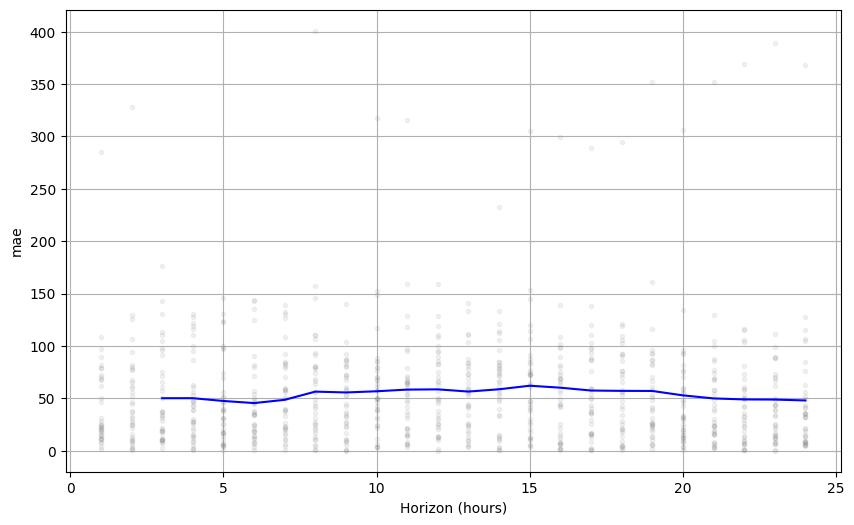

/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


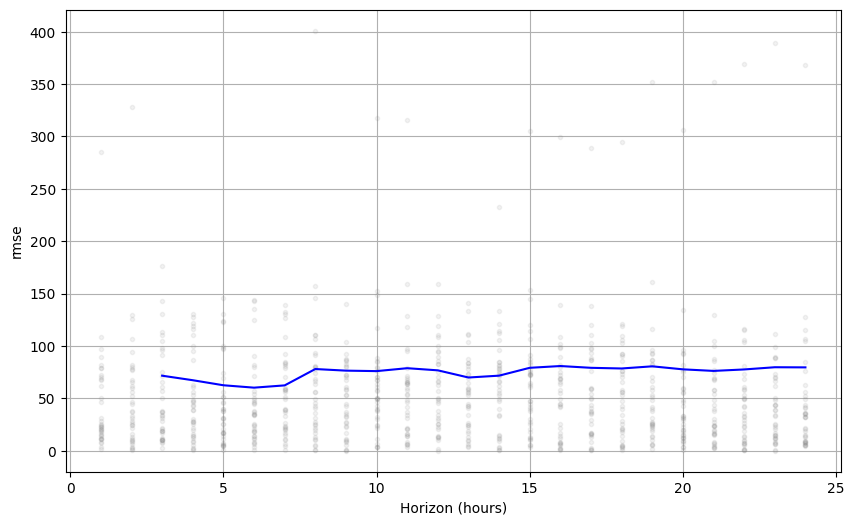

In [8]:
#plot error

from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

fig1 = plot_cross_validation_metric(df_cv_test, metric='mae')
plt.show()
plt.close(fig1)

fig2 = plot_cross_validation_metric(df_cv_test, metric='rmse')
plt.show()
plt.close(fig2)


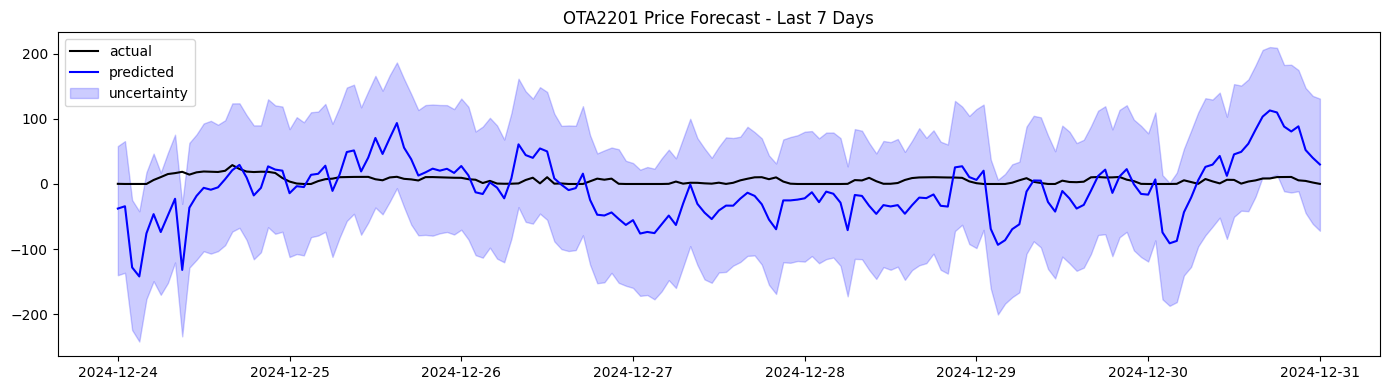

In [9]:
# Step 1: predict on known data
future = df_prophet.drop(columns='y')
forecast = m.predict(future)

# Step 2: plot - last 7 days actual vs predicted
cutoff = df_prophet['ds'].max() - pd.Timedelta(days=7)
mask_actual = df_prophet['ds'] >= cutoff
mask_forecast = forecast['ds'] >= cutoff

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_prophet.loc[mask_actual, 'ds'],
        df_prophet.loc[mask_actual, 'y'],
        label='actual', color='black')
ax.plot(forecast.loc[mask_forecast, 'ds'],
        forecast.loc[mask_forecast, 'yhat'],
        label='predicted', color='blue')
ax.fill_between(forecast.loc[mask_forecast, 'ds'],
                forecast.loc[mask_forecast, 'yhat_lower'],
                forecast.loc[mask_forecast, 'yhat_upper'],
                alpha=0.2, color='blue', label='uncertainty')
ax.legend()
ax.set_title('OTA2201 Price Forecast - Last 7 Days')
plt.tight_layout()
plt.show()

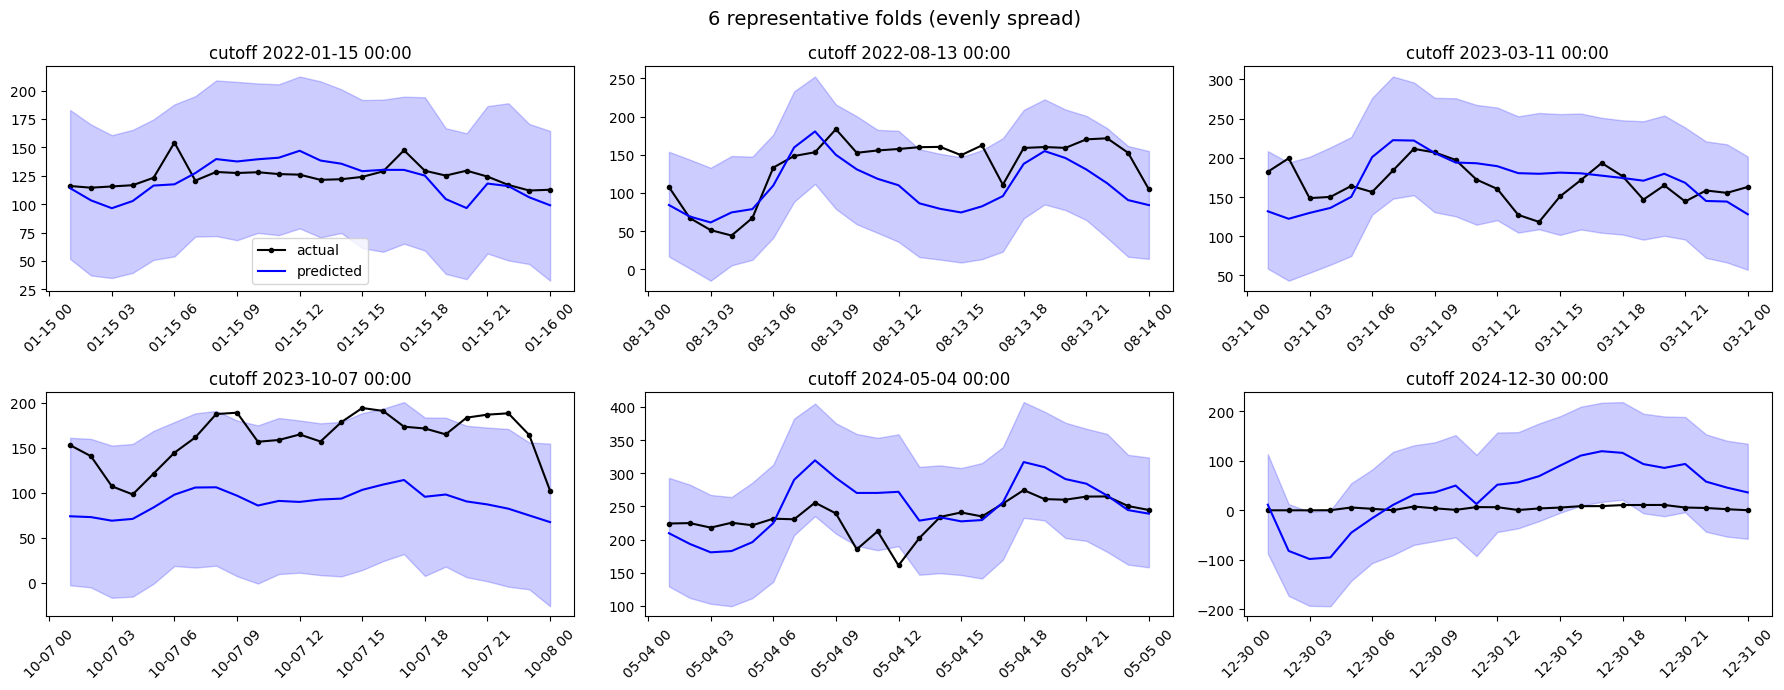

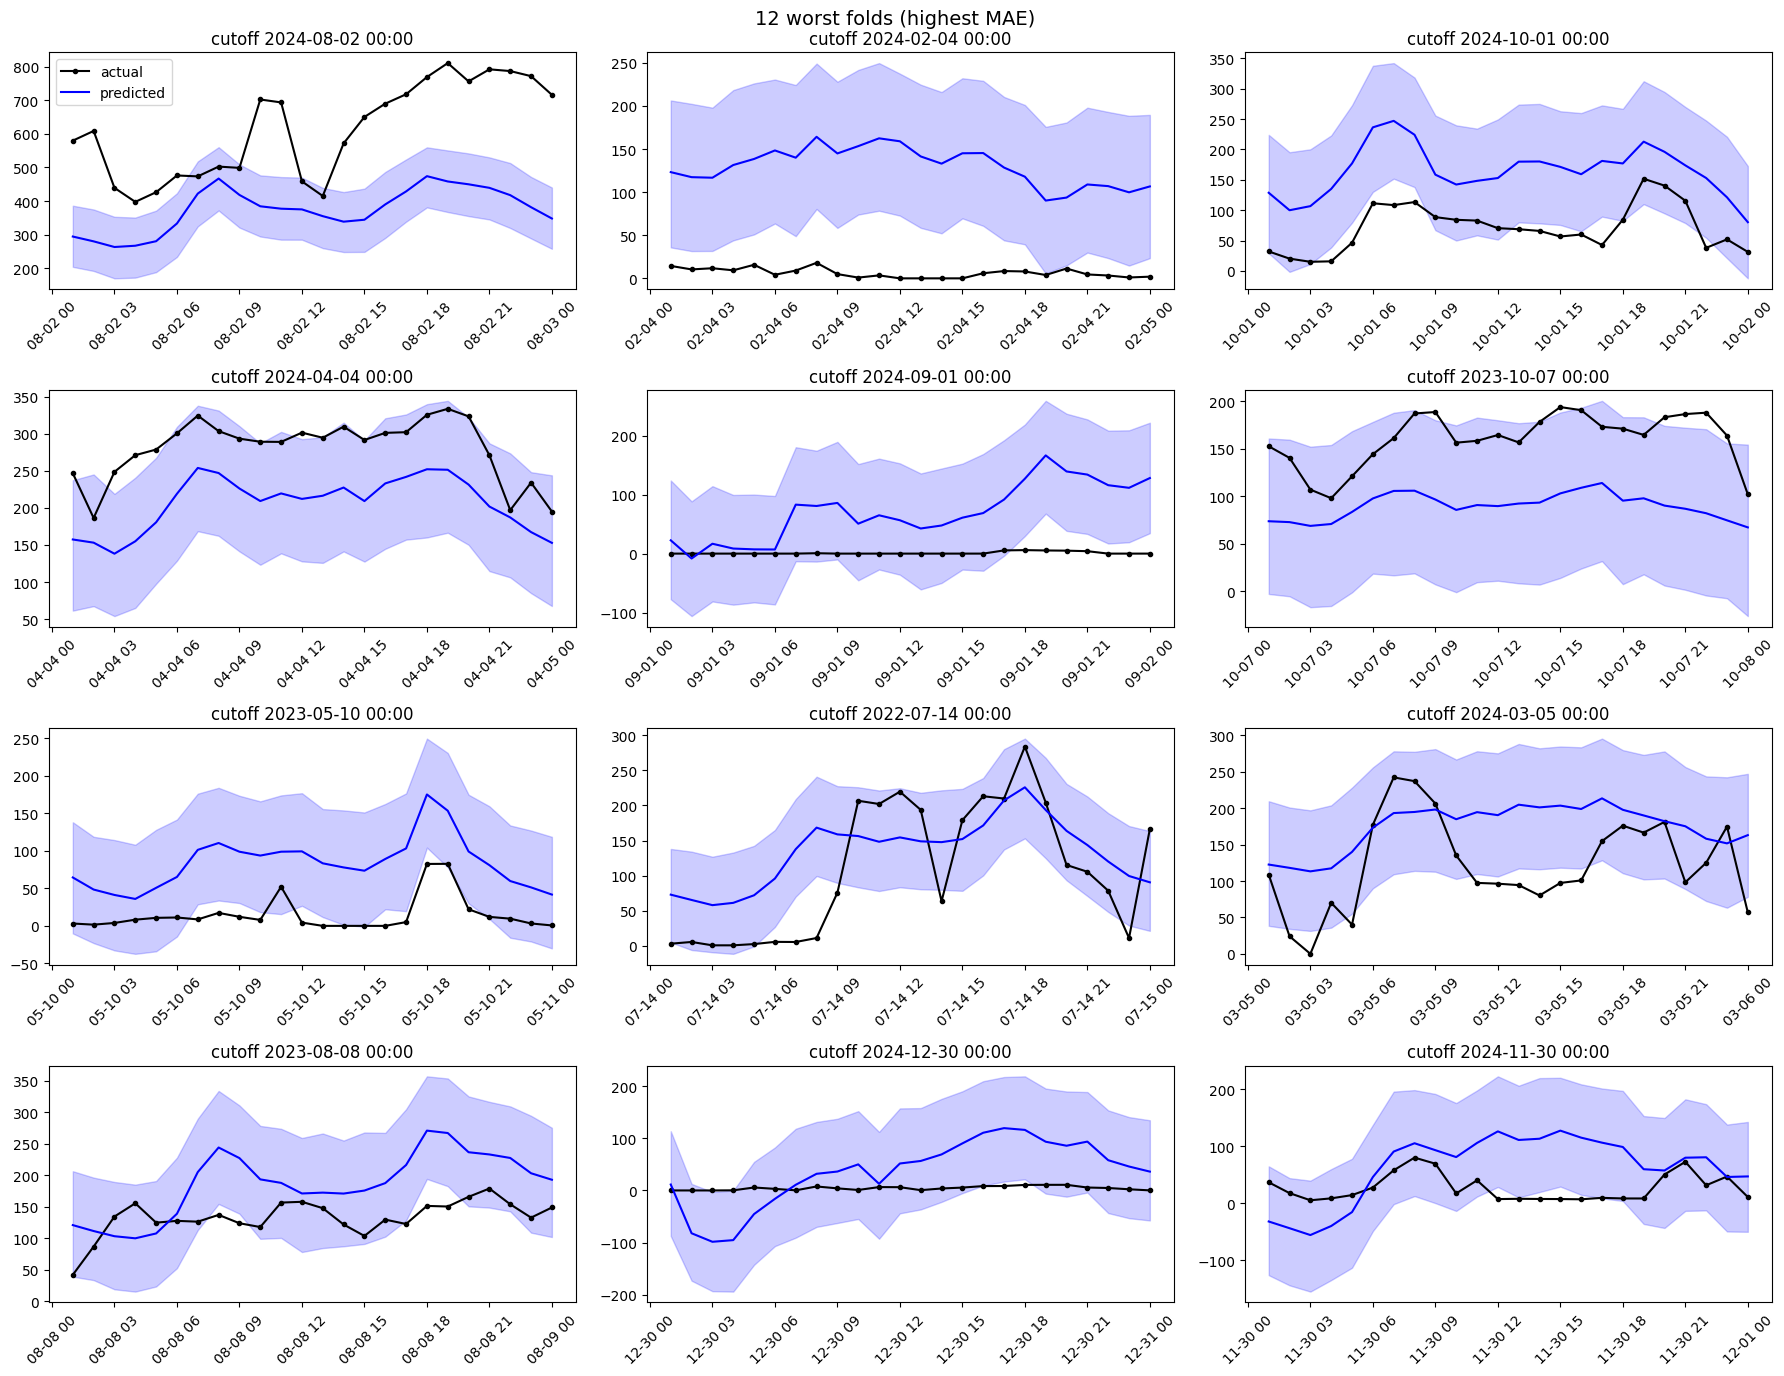

In [10]:
import numpy as np

cutoffs = sorted(df_cv_test['cutoff'].unique())

# --- reusable plotter ---
def plot_folds(sel, nrows, ncols, suptitle):
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3.5*nrows), sharey=False)
    for ax, co in zip(axes.ravel(), sel):
        fold = df_cv_test[df_cv_test['cutoff'] == co].sort_values('ds')
        ax.plot(fold['ds'], fold['y'],    label='actual',    color='black', marker='.')
        ax.plot(fold['ds'], fold['yhat'], label='predicted', color='blue')
        ax.fill_between(fold['ds'], fold['yhat_lower'], fold['yhat_upper'],
                        alpha=0.2, color='blue')
        ax.set_title(f"cutoff {pd.Timestamp(co):%Y-%m-%d %H:%M}")
        ax.tick_params(axis='x', rotation=45)
    # hide any unused panels
    for ax in axes.ravel()[len(sel):]:
        ax.set_visible(False)
    axes.ravel()[0].legend()
    fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()

# --- 6 representative folds, evenly spread across the test period ---
picks = np.linspace(0, len(cutoffs) - 1, 6, dtype=int)
sel_normal = [cutoffs[i] for i in picks]
plot_folds(sel_normal, 2, 3, "6 representative folds (evenly spread)")

# --- 12 worst folds by MAE ---
fold_mae = (df_cv_test.assign(ae=lambda d: (d['y'] - d['yhat']).abs())
            .groupby('cutoff')['ae'].mean().sort_values(ascending=False))
sel_worst = fold_mae.head(12).index.tolist()
plot_folds(sel_worst, 4, 3, "12 worst folds (highest MAE)")

count     37.000000
mean      53.300744
std       38.595598
min       11.032427
25%       34.284349
50%       52.989202
75%       61.440764
max      237.948663
Name: fold_MAE, dtype: float64


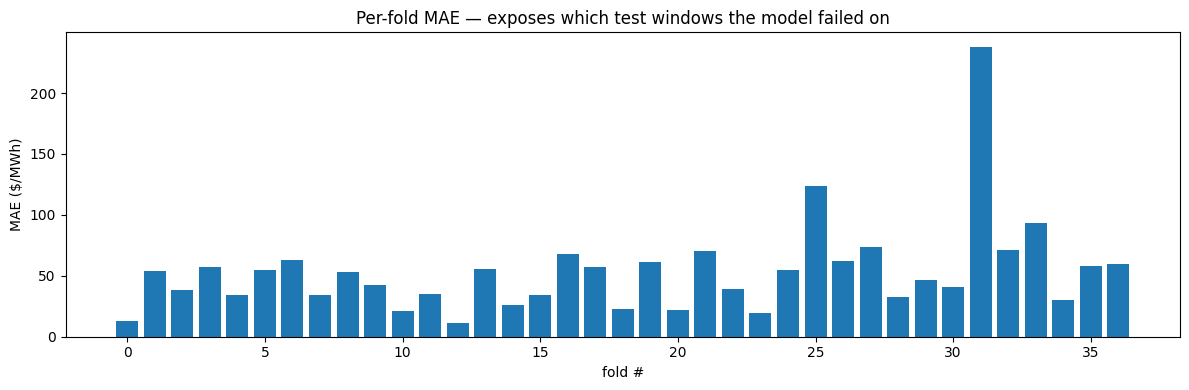

In [11]:
# 3. Per-fold error, so you can see the variance the aggregate metrics hide
fold_err = (df_cv_test
            .assign(abs_err=lambda d: (d['y'] - d['yhat']).abs())
            .groupby('cutoff')['abs_err']
            .mean()
            .reset_index(name='fold_MAE'))

print(fold_err['fold_MAE'].describe())

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(fold_err)), fold_err['fold_MAE'])
ax.set_xlabel('fold #'); ax.set_ylabel('MAE ($/MWh)')
ax.set_title('Per-fold MAE — exposes which test windows the model failed on')
plt.tight_layout()
plt.show()

In [12]:
from prophet.utilities import regressor_coefficients

coefs = regressor_coefficients(m)
coefs = coefs.reindex(coefs['coef'].abs().sort_values(ascending=False).index)
print(coefs.to_string())

                               regressor  regressor_mode    center  coef_lower      coef  coef_upper
1                                 Diesel  multiplicative  0.005762    1.466019  1.466019    1.466019
5                                  Hydro  multiplicative  0.527976    1.086106  1.086106    1.086106
3                                    Gas  multiplicative  0.399493    0.992190  0.992190    0.992190
38            SI_TKA__active_storage_mm³  multiplicative  0.494732   -0.906521 -0.906521   -0.906521
60                        demand_GWh_LSI  multiplicative  0.788115    0.889020  0.889020    0.889020
59                        demand_GWh_LNI  multiplicative  0.535121   -0.812670 -0.812670   -0.812670
62                        demand_GWh_USI  multiplicative  0.639769    0.608128  0.608128    0.608128
37                  SI_TKA__lake_level_m  multiplicative  0.501134    0.601016  0.601016    0.601016
36                        dunedin_temp_c  multiplicative  0.418626   -0.577167 -0.577167   

In [13]:
import numpy as np

# In-sample: predict on the training data itself
insample = m.predict(df_prophet.drop(columns='y'))
train_mae  = np.mean(np.abs(df_prophet['y'].values - insample['yhat'].values))
train_rmse = np.sqrt(np.mean((df_prophet['y'].values - insample['yhat'].values)**2))

# Out-of-sample: from the CV you already have
cv_mae  = np.mean(np.abs(df_cv_test['y'] - df_cv_test['yhat']))
cv_rmse = np.sqrt(np.mean((df_cv_test['y'] - df_cv_test['yhat'])**2))

print(f"Train MAE:  {train_mae:6.2f}   |  CV MAE:  {cv_mae:6.2f}")
print(f"Train RMSE: {train_rmse:6.2f}   |  CV RMSE: {cv_rmse:6.2f}")
print(f"Gap (CV/Train MAE ratio): {cv_mae/train_mae:.2f}x")

Train MAE:   42.29   |  CV MAE:   53.30
Train RMSE:  77.02   |  CV RMSE:  74.74
Gap (CV/Train MAE ratio): 1.26x


# Predict

In [14]:
# We might split it beforehand so we have 24 hours of feature to use to predict the price

# Build a future dataframe for next 24 hours
future = m.make_future_dataframe(
    periods=24,
    freq='h',
    include_history=False   # just the forecast window
)

# Attach regressor forecasts for those 24 hours
future['demand_north']      = demand_forecast_24h
future['wind_generation']    = wind_forecast_24h
future['hydro_storage']     = hydro_now   # relatively static
future['temperature_auckland'] = temp_forecast_24h

forecast = m.predict(future)

# Key output columns:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

NameError: name 'demand_forecast_24h' is not defined